In [108]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from helpers_takarada import * 
import os
plt.rcParams.update({'savefig.dpi':300, 'axes.labelweight':'normal'})
matplotlib.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.labelsize'] = 14      # xlabel and ylabel
plt.rcParams['xtick.labelsize'] = 12     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12     # y-axis tick labels
plt.rcParams['axes.titlesize'] = 16      # title size

from matplotlib import rc
preamble = r'''
\usepackage{physics} \usepackage{upgreek} \usepackage{mhchem} \usepackage{bm}
'''
import matplotlib.colors as colors
plt.rc('text.latex', preamble=preamble)
rc('text', usetex=True)

def colorFader(c1, c2, mix=0.5):
    c1 = np.array(matplotlib.colors.to_rgb(c1))
    c2 = np.array(matplotlib.colors.to_rgb(c2))
    return matplotlib.colors.to_hex((1-mix)*c1 + mix*c2)
from module_takarada import * 
parameters1 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-10,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-10,
'dmu' : 5.,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

parameters2 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-10,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-10,
'dmu' : 5.,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

0.35828163649625633 (-0.20685325001744295+0j) (-0+0j)
chi_j_rho is zero: True
correction is zero: True


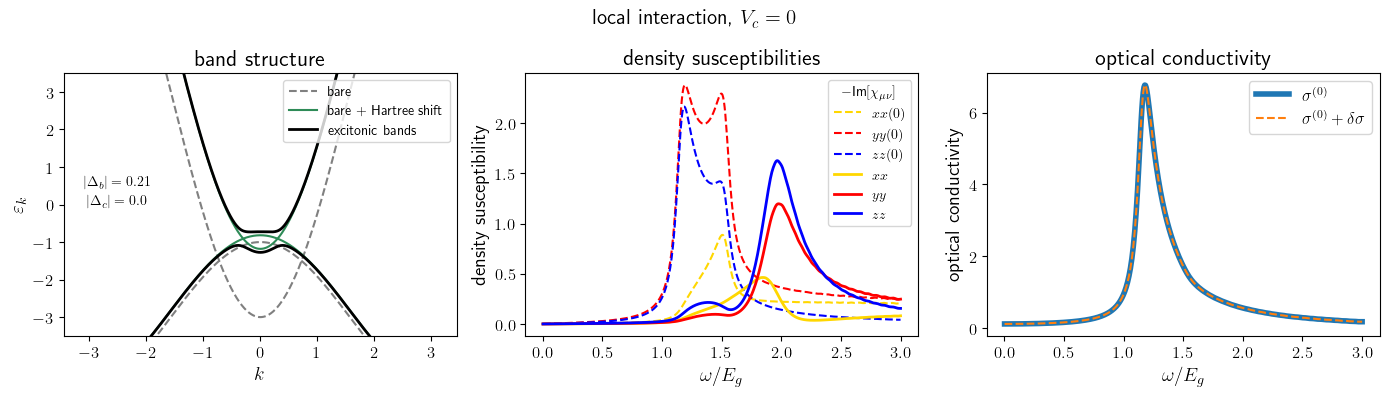

In [109]:
a = 1.
b = 0.5
t12 = 0.
delta = 0.

t = 1.
t_ = 3.
Vc = 0.
Vb = 2.
epsilon = 3.
epsilon_ = 3.

phys_parameters = [b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta]

mu0 = 0.
include_hartree = True

Nk = 1000
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()
m.mu = 0.5 * (np.min(m.energije[1]) + np.max(m.energije[0]))
gap = np.min(m.energije[1]) - np.max(m.energije[0])
print(gap, m.delta_b,  m.delta_c)

#plt.plot(m.energije[0])
#plt.plot(m.energije[1])

tok = j_tok(m.K, phys_parameters, m.mu)
rhos, thetas = rho_operators(m.K, phys_parameters, include_hartree)

omegas = np.linspace(0.001, m.gap*3, 501)
Gamma = 0.01
chijj, dchijj, chirhorho, chirhoj = chi_j_j(m.K, tok, rhos, thetas, m.vecs, m.energije, m.fs, omegas, Gamma)
chi0, chi = chi_rho_rho(m.K, rhos, thetas, m.vecs, m.energije, m.fs, omegas, Gamma)
sigma_omega = -chijj.imag / omegas
dsigma_omega = -dchijj.imag / omegas
#plt.plot(omegas/gap, sigma_omega, '.-')
#plt.plot(omegas/gap, sigma_omega + dsigma_omega, '--')
print(rf'chi_j_rho is zero: {np.allclose(chirhoj, 0)}')
print(rf'correction is zero: {np.allclose(dsigma_omega, 0)}')

fig, ax = plt.subplots(ncols=3, figsize=(14,4))

ax[0].plot(m.K, 2*t*np.cos(m.K) - epsilon, color='grey', ls='dashed', label='bare')
ax[0].plot(m.K, -2*t_*np.cos(m.K) + epsilon_, color='grey', ls='dashed')

ax[0].plot(m.K, 2*t*np.cos(m.K) - epsilon + (Vb + Vc) * np.sum(m.rho[1,1,:]).real / m.Nk, color='seagreen', label='bare + Hartree shift')
ax[0].plot(m.K, -2*t_*np.cos(m.K) + epsilon_ + (Vb + Vc) * np.sum(m.rho[0,0,:]).real / m.Nk, color='seagreen')

ax[0].plot(m.K, m.energije[0], color='black', lw=2, label='excitonic bands')
ax[0].plot(m.K, m.energije[1], color='black', lw=2)
ax[0].set_ylim(-3.5,3.5)
ax[0].legend()
ax[0].set_xlabel(r'$k$')
ax[0].set_ylabel(r'$\varepsilon_k$')
ax[0].text(-2.5, 0.5, rf'$|\Delta_b| = {np.round(np.abs(m.delta_b), 2)}$', ha='center')
ax[0].text(-2.5, 0, rf'$|\Delta_c| = {np.round(np.abs(m.delta_c), 2)}$', ha='center')

ax[1].plot(omegas/gap, -chi0[1,1].imag, color='gold', ls='dashed', label='$xx(0)$')
ax[1].plot(omegas/gap, -chi0[2,2].imag, color='red', ls='dashed', label='$yy(0)$')
ax[1].plot(omegas/gap, -chi0[3,3].imag, color='blue', ls='dashed', label='$zz(0)$')

ax[1].plot(omegas/gap, -chi[1,1].imag, color='gold', lw=2, label='$xx$')
ax[1].plot(omegas/gap, -chi[2,2].imag, color='red', lw=2, label='$yy$')
ax[1].plot(omegas/gap, -chi[3,3].imag, color='blue', lw=2, label='$zz$')
ax[1].legend().set_title(r'$-\text{Im}[\chi_{\mu\nu}]$')
ax[1].set_xlabel(r'$\omega/E_g$')
ax[1].set_ylabel(r'density susceptibility')

ax[2].plot(omegas/gap, -chijj.imag/omegas, lw=4, label=r'$\sigma^{(0)}$')
ax[2].plot(omegas/gap, -chijj.imag/omegas - dchijj.imag/omegas, ls='dashed', label=r'$\sigma^{(0)} + \delta \sigma$')
ax[2].legend(fontsize=12)
ax[2].set_xlabel(r'$\omega/E_g$')
ax[2].set_ylabel(r'optical conductivity')

ax[0].set_title(r'band structure')
ax[1].set_title(r'density susceptibilities')
ax[2].set_title(r'optical conductivity')

fig.suptitle(r'local interaction, $V_c=0$', fontsize=15)
plt.tight_layout()
os.chdir('/Users/ana/Desktop/takarada/slike')

plt.savefig('local-example.pdf')

0.22536603388280407 (-0.07439727022373506+0j) (-0.0571942307325321+0j)
chi_j_rho is zero: False
correction is zero: False


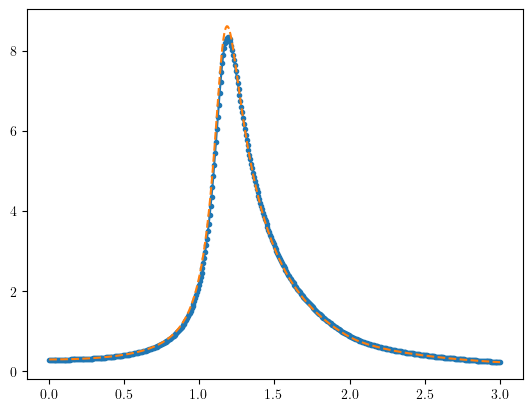

In [ ]:
a = 1.
b = 0.5
t12 = 0.
delta = 0.

t = 1.
t_ = 3.
Vc = 1.
Vb = 1.
epsilon = 3.
epsilon_ = 3.

phys_parameters = [b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta]

mu0 = 0.
include_hartree = True

Nk = 1000
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()
m.mu = 0.5 * (np.min(m.energije[1]) + np.max(m.energije[0]))
gap = np.min(m.energije[1]) - np.max(m.energije[0])
print(gap, m.delta_b,  m.delta_c)

#plt.plot(m.energije[0])
#plt.plot(m.energije[1])

tok = j_tok(m.K, phys_parameters, m.mu)
rhos, thetas = rho_operators(m.K, phys_parameters, include_hartree)

omegas = np.linspace(0.001, m.gap*3, 501)
Gamma = 0.01
chijj, dchijj, chirhorho, chirhoj = chi_j_j(m.K, tok, rhos, thetas, m.vecs, m.energije, m.fs, omegas, Gamma)
sigma_omega = -chijj.imag / omegas
dsigma_omega = -dchijj.imag / omegas
plt.plot(omegas/gap, sigma_omega, '.-')
plt.plot(omegas/gap, sigma_omega + dsigma_omega, '--')
print(rf'chi_j_rho is zero: {np.allclose(chirhoj, 0)}')
print(rf'correction is zero: {np.allclose(dsigma_omega, 0)}')

In [4]:
t0 = 2.
sigma = 0.02
dt = 0.005
Omega = 0.
A0 = 0.01

tok = j_tok(m.K, phys_parameters, m.mu)
rhos, thetas = rho_operators(m.K, phys_parameters, include_hartree)

perturbation_operator = tok
measure_operators = tok

t_max = 450

time, measurements = simulate_pulz(m.K, m.rho, phys_parameters, include_hartree, perturbation_operator, measure_operators, A0, t0, sigma, Omega, dt, t_max)
measurements = measurements[:,0].real


0.0
0.0005555555555555556
0.0011111111111111111
0.0016666666666666668
0.0022222222222222222
0.002777777777777778
0.0033333333333333335
0.0038888888888888888
0.0044444444444444444
0.005
0.005555555555555556
0.006111111111111111
0.006666666666666667
0.007222222222222222
0.0077777777777777776
0.008333333333333333
0.008888888888888889
0.009444444444444445
0.01
0.010555555555555556
0.011111111111111112
0.011666666666666667
0.012222222222222223
0.012777777777777779
0.013333333333333334
0.013888888888888888
0.014444444444444444
0.015
0.015555555555555555
0.01611111111111111
0.016666666666666666
0.017222222222222222
0.017777777777777778
0.018333333333333333
0.01888888888888889
0.019444444444444445
0.02
0.020555555555555556
0.021111111111111112
0.021666666666666667
0.022222222222222223
0.02277777777777778
0.023333333333333334
0.02388888888888889
0.024444444444444446
0.025
0.025555555555555557
0.026111111111111113
0.02666666666666667
0.02722222222222222
0.027777777777777776
0.028333333333333332
